In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os,glob

In [7]:
def mean_sq_displ(x_data,y_data):
    msd=np.zeros(len(x_data))
    for t_lag in range(0,len(x_data)):
        a=0
        for i in range(len(x_data)):
            if((i+t_lag)<len(x_data)):
                msd[t_lag]+=((x_data[i+t_lag]-x_data[i])**2+(y_data[i+t_lag]-y_data[i])**2)
                a+=1
        msd[t_lag]/=a
    return(msd)

In [8]:
def piece_wise_msd(T,x_data,y_data): ### Takes in time window T, x_data and y_data
    
    start_time=int(T/2)  ### Initial start time in \Delta R_t
    end_time=len(x_data)-int(1*T/2)  ### Last time point that we can get

    alpha=[0 for i in range(end_time-start_time)]
    coeff=[0 for i in range(end_time-start_time)]
    
    msd=[[0 for j in range(T)] for i in range(end_time-start_time)]

    t_counter=-1
    for t_point in range(start_time,end_time,1):
        t_counter+=1
        for t_lag in range(T):
            t_prime_counter=0
            for t_prime in range(t_point-int(T/2),t_point+int(T/2)+1):
                if((t_prime+t_lag)<=(t_point+T/2)):

                    msd[t_counter][t_lag]+=((x_data[t_prime+t_lag]-x_data[t_prime])**2+
                                        (y_data[t_prime+t_lag]-y_data[t_prime])**2)

                t_prime_counter+=1
            msd[t_counter][t_lag]/=t_prime_counter

        alpha[t_counter],coeff[t_counter]=np.polyfit([np.log(ele) for ele in range(1,int(T/2))],[np.log(ele) for ele in msd[t_counter][1:int(T/2)]],1)  

    return(alpha,coeff,msd)



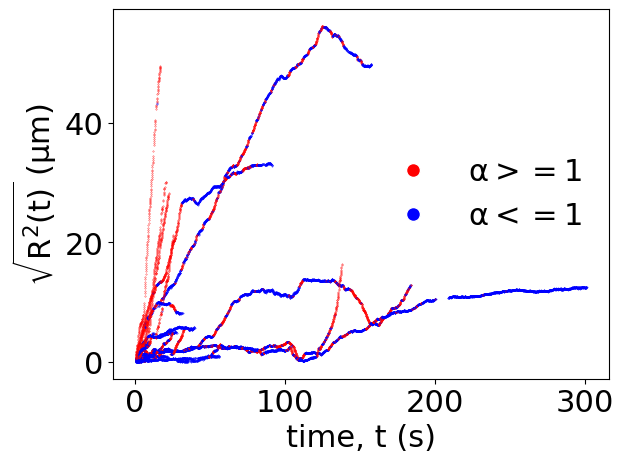

In [37]:
from scipy import signal
import pandas as pd
plt.rcParams.update({'font.size': 22})
fig,ax=plt.subplots(1)
sc_array,tot_intensity=[],[]

active_velocity,passive_coeff=[],[]
# alpha_values,cond_area=[],[]
count_condensates=0
for file_name in ['Individual_1.csv','Individual_2.csv','Individual_3.csv','Individual_4.csv',\
                 'Individual_5.csv','Individual_6.csv']:
    df=pd.read_csv('Native/'+file_name)
    
    non_zero=0
    
    for track_wa in df['Condensate_ID'].unique():
        if(count_condensates<20):
            count_condensates+=1
            filtered_data=df[(df['Condensate_ID']==track_wa)]
            filtered_data=filtered_data[(filtered_data['Angle (degrees)'].notna())]

            x_data=filtered_data['x_position (um)'].to_numpy().ravel()
            y_data=filtered_data['y_position (um)'].to_numpy().ravel()
            time_data=filtered_data['Times (s)'].to_numpy().ravel()
            T=12   ###Window time
            start_time=int(T/2)  ### Initial start time in \Delta R_t
            end_time=len(x_data)-int(1*T/2)
            t_data=[time_data[jk]-time_data[0] for jk in range(len(time_data))]
            p_a=[0 for i in range(end_time-start_time)]

            alpha,coeff,msd=piece_wise_msd(T,x_data,y_data)

            for t_counter in range(len(alpha)):
                if(alpha[t_counter]>1.) :
                    p_a[t_counter]=1

                    active_velocity.append(np.sqrt(np.exp(coeff[t_counter])))

                    kl=t_counter+int(T/2)
                    ax.plot(t_data[kl],np.sqrt((x_data[kl]-x_data[0])**2+(y_data[kl]-y_data[0])**2),marker='.',ms=0.5,color='r')
                else:
                    p_a[t_counter]=0
                    kl=t_counter+int(T/2)
                    passive_coeff.append(np.exp(coeff[t_counter])/4)
                    ax.plot(t_data[kl],np.sqrt((x_data[kl]-x_data[0])**2+(y_data[kl]-y_data[0])**2) ,marker='.',ms=0.5,color='b')

        ax.set_xlabel('time, t (s)')

        ax.set_ylabel(r'$\mathrm {\sqrt{R^2(t)} \;(\mu m)}$')

colors=['r','b']
labels=[r'$\mathrm{\alpha>=1}$',r'$\mathrm{\alpha<=1}$']
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for color in colors]

ax.legend(handles, labels, loc='best',frameon=False)
plt.title("
plt.savefig("Active_vs_Passive/Active_Native_pARF19.eps",bbox_inches='tight')
plt.show()
        



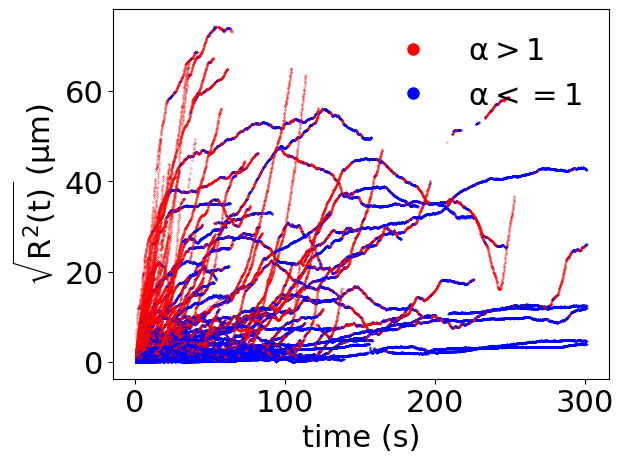

In [47]:
from scipy import signal
import pandas as pd
plt.rcParams.update({'font.size': 22})
fig,ax=plt.subplots(1)
sc_array,tot_intensity=[],[]

active_velocity,passive_coeff=[],[]
# alpha_values,cond_area=[],[]
count_condensates=0
for file_name in ['Individual_1.csv','Individual_2.csv','Individual_3.csv','Individual_4.csv',\
                 'Individual_5.csv','Individual_6.csv']:
    df=pd.read_csv('Native/'+file_name)
    
    non_zero=0
    
    for track_wa in df['Condensate_ID'].unique():
        if(count_condensates<1000):
            count_condensates+=1
            filtered_data=df[(df['Condensate_ID']==track_wa)]
            filtered_data=filtered_data[(filtered_data['Angle (degrees)'].notna())]

            x_data=filtered_data['x_position (um)'].to_numpy().ravel()
            y_data=filtered_data['y_position (um)'].to_numpy().ravel()
            time_data=filtered_data['Times (s)'].to_numpy().ravel()
            T=12   ###Window time
            start_time=int(T/2)  ### Initial start time in \Delta R_t
            end_time=len(x_data)-int(1*T/2)
            t_data=[time_data[jk]-time_data[0] for jk in range(len(time_data))]
            p_a=[0 for i in range(end_time-start_time)]

            alpha,coeff,msd=piece_wise_msd(T,x_data,y_data)

            for t_counter in range(len(alpha)):
                if(alpha[t_counter]>1.) :
                    p_a[t_counter]=1

                    active_velocity.append(np.sqrt(np.exp(coeff[t_counter])))

                    kl=t_counter+int(T/2)
                    ax.plot(t_data[kl],np.sqrt((x_data[kl]-x_data[0])**2+(y_data[kl]-y_data[0])**2) ,marker='.',ms=0.5,color='r')
                else:
                    p_a[t_counter]=0
                    kl=t_counter+int(T/2)
                    passive_coeff.append(np.exp(coeff[t_counter])/4)
                    ax.plot(t_data[kl],np.sqrt((x_data[kl]-x_data[0])**2+(y_data[kl]-y_data[0])**2) ,marker='.',ms=0.5,color='b')

        ax.set_xlabel('time (s)')

        ax.set_ylabel(r'$\mathrm {\sqrt{R^2(t)} \;(\mu m)}$')

colors=['r','b']
labels=[r'$\mathrm{\alpha>1}$',r'$\mathrm{\alpha<=1}$']
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for color in colors]

ax.legend(handles, labels, loc='best',frameon=False)
plt.savefig("Active_vs_Passive/pdfs/pARF19.pdf",bbox_inches='tight')
plt.show()
        



In [10]:
ls

Active_vs_Passive/
Active_vs_passive.ipynb
Angle_LAT.pdf
Area_LAT.pdf
Area_vs_t.ipynb
Diff_Angle_speed_WT_vs_LatB.pdf
Diff_Area_speed_WT_LatB.pdf
Experiment_analysis.ipynb
Heatmap.ipynb
KL_divergence.pdf
LatB/
LatB10minuteParticleSizes_530_Manual.xlsx
Native/
PDF_speed_discrete.pdf
Prob_Angle_LAT.pdf
Prob_Area_LAT.pdf
Prob_WT_Area.pdf
Prob_WT_speed_angle.pdf
WT_Area.pdf
WT_speed_angle.pdf
pARF19_Area_speed_LAT.pdf
pARF7/
pUBQ10/


In [12]:
from scipy import signal
import pandas as pd
plt.rcParams.update({'font.size': 22})
fig,ax=plt.subplots(1)
sc_array,tot_intensity=[],[]

active_velocity,passive_coeff=[],[]
# alpha_values,cond_area=[],[]
count_condensates=0
for file_name in ['Individual_1.csv','Individual_2.csv','Individual_3.csv','Individual_4.csv',\
                 'Individual_5.csv','Individual_6.csv']:
    df=pd.read_csv('Native/'+file_name)
    
    non_zero=0
    
    for track_wa in df['Condensate_ID'].unique():
        if(count_condensates<1000):
            count_condensates+=1
            filtered_data=df[(df['Condensate_ID']==track_wa)]
            filtered_data=filtered_data[(filtered_data['Angle (degrees)'].notna())]

            x_data=filtered_data['x_position (um)'].to_numpy().ravel()
            y_data=filtered_data['y_position (um)'].to_numpy().ravel()
            time_data=filtered_data['Times (s)'].to_numpy().ravel()
            T=12   ###Window time
            start_time=int(T/2)  ### Initial start time in \Delta R_t
            end_time=len(x_data)-int(1*T/2)
            if(end_time>0):
                t_data=[time_data[jk]-time_data[0] for jk in range(len(time_data))]
                p_a=[0 for i in range(end_time-start_time)]
    
                alpha,coeff,msd=piece_wise_msd(T,x_data,y_data)
                ax.plot(t_data[0:end_time],[np.sqrt((x_data[kl]-x_data[0])**2+(y_data[kl]-y_data[0])**2) for kl in range(0,end_time)],alpha=0.3,lw=1,color='k')
                for t_counter in range(len(alpha)):
                    if(alpha[t_counter]>1.) :
                        p_a[t_counter]=1
    
                        active_velocity.append(np.sqrt(np.exp(coeff[t_counter])))
    
                        kl=t_counter+int(T/2)
                        ax.plot(t_data[kl],np.sqrt((x_data[kl]-x_data[0])**2+(y_data[kl]-y_data[0])**2) ,marker='.',ms=1,color='#FF800E')
                    else:
                        p_a[t_counter]=0
                        kl=t_counter+int(T/2)
                        passive_coeff.append(np.exp(coeff[t_counter])/4)
                        ax.plot(t_data[kl],np.sqrt((x_data[kl]-x_data[0])**2+(y_data[kl]-y_data[0])**2) ,marker='.',ms=1,color='#006BA4')

ax.set_xlabel('time (s)')

ax.set_ylabel(r'$\mathrm {R(t) \;(\mu m)}$')

colors=['#FF800E','#006BA4']
labels=[r'$\mathrm{\alpha_{local}>1}$',r'$\mathrm{\alpha_{local}\leq 1}$']
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for color in colors]
plt.ylim([0,70])
ax.legend(handles, labels, loc='best',frameon=False)
plt.savefig("Active_vs_Passive/pdfs/pARF19.pdf",bbox_inches='tight')
plt.show()
        



KeyboardInterrupt: 

In [ ]:
ls

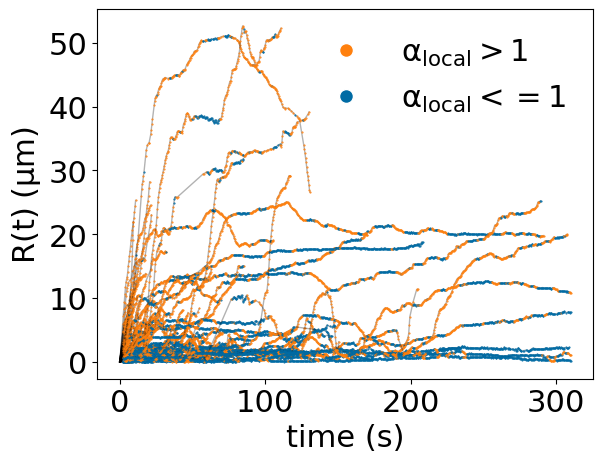

In [4]:
from scipy import signal
import pandas as pd
plt.rcParams.update({'font.size': 22})
fig,ax=plt.subplots(1)
sc_array,tot_intensity=[],[]

active_velocity,passive_coeff=[],[]
# alpha_values,cond_area=[],[]
count_condensates=0
for file_name in ['Individual_2.csv','Individual_3.csv','Individual_7.csv',\
                 'Individual_8.csv','Individual_10.csv']:
    df=pd.read_csv('pUBQ10/native/'+file_name)
    
    non_zero=0
    
    for track_wa in df['Condensate_ID'].unique():
        
        filtered_data=df[(df['Condensate_ID']==track_wa)]
        filtered_data=filtered_data[(filtered_data['Angle (degrees)'].notna())]

        x_data=filtered_data['x_position (um)'].to_numpy().ravel()
        y_data=filtered_data['y_position (um)'].to_numpy().ravel()
        time_data=filtered_data['Times (s)'].to_numpy().ravel()
        T=12   ###Window time
        start_time=int(T/2)  ### Initial start time in \Delta R_t
        end_time=len(x_data)-int(1*T/2)
        if end_time>0:
            t_data=[time_data[jk]-time_data[0] for jk in range(len(time_data))]
            p_a=[0 for i in range(end_time-start_time)]
    
            alpha,coeff,msd=piece_wise_msd(T,x_data,y_data)
            ax.plot(t_data[0:end_time],[np.sqrt((x_data[kl]-x_data[0])**2+(y_data[kl]-y_data[0])**2) for kl in range(0,end_time)],alpha=0.3,lw=1,color='k')
            
            for t_counter in range(len(alpha)):
                if(alpha[t_counter]>1.) :
                    p_a[t_counter]=1
    
                    active_velocity.append(np.sqrt(np.exp(coeff[t_counter])))
    
                    kl=t_counter+int(T/2)
                    ax.plot(t_data[kl],np.sqrt((x_data[kl]-x_data[0])**2+(y_data[kl]-y_data[0])**2) ,marker='.',ms=1,color='#FF800E')
                else:
                    p_a[t_counter]=0
                    kl=t_counter+int(T/2)
                    passive_coeff.append(np.exp(coeff[t_counter])/4)
                    ax.plot(t_data[kl],np.sqrt((x_data[kl]-x_data[0])**2+(y_data[kl]-y_data[0])**2) ,marker='.',ms=1,color='#006BA4')

ax.set_xlabel('time (s)')

ax.set_ylabel(r'$\mathrm {R(t) \;(\mu m)}$')

colors=['#FF800E','#006BA4']
labels=[r'$\mathrm{\alpha_{local}>1}$',r'$\mathrm{\alpha_{local} \leq 1}$']
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for color in colors]

ax.legend(handles, labels, loc='best',frameon=False)
plt.savefig("Active_vs_Passive/pdfs/pUBQ10_native.pdf",bbox_inches='tight')
plt.show()
        



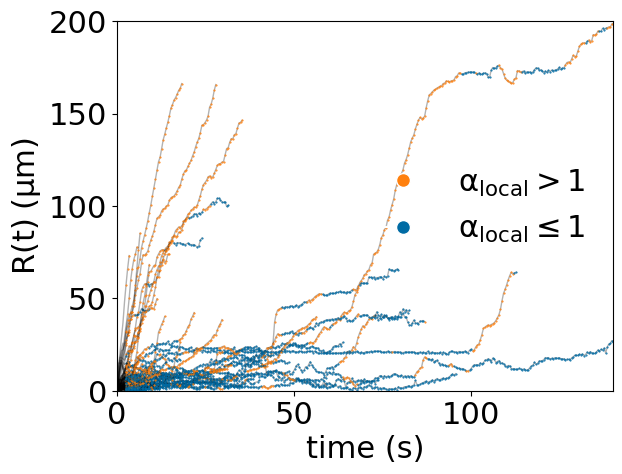

In [5]:
from scipy import signal
import pandas as pd
plt.rcParams.update({'font.size': 22})
fig,ax=plt.subplots(1)
sc_array,tot_intensity=[],[]

active_velocity,passive_coeff=[],[]
# alpha_values,cond_area=[],[]
count_condensates=0

for file_name in ['Individual_1.xlsx','Individual_2.xlsx','Individual_3.xlsx',\
                 'Individual_4.xlsx','Individual_5.xlsx','Individual_6.xlsx']:
    df=pd.read_excel('pARF7/'+file_name)
    
    non_zero=0
    
    for track_wa in df['TRACK_ID'].unique():
        if isinstance(track_wa, int):
            filtered_data=df[(df['TRACK_ID']==track_wa)]
            
        
            x_data=filtered_data['POSITION_X'].to_numpy().ravel()
            y_data=filtered_data['POSITION_Y'].to_numpy().ravel()
            time_data=filtered_data['T (s)'].to_numpy().ravel()
            T=12   ###Window time
            start_time=int(T/2)  ### Initial start time in \Delta R_t
            end_time=len(x_data)-int(T/2)
            
            if(end_time>0):
            
                t_data=[time_data[jk]-time_data[0] for jk in range(len(time_data))]
                p_a=[0 for i in range(end_time-start_time)]
            
                alpha,coeff,msd=piece_wise_msd(T,x_data,y_data)
                
                ax.plot(t_data[0:end_time],[np.sqrt((x_data[kl]-x_data[0])**2+(y_data[kl]-y_data[0])**2) for kl in range(0,end_time)],alpha=0.3,lw=1,color='k')
                
                for t_counter in range(len(alpha)):
                    if(alpha[t_counter]>1.) :
                        p_a[t_counter]=1
            
                        active_velocity.append(np.sqrt(np.exp(coeff[t_counter])))
            
                        kl=t_counter+int(T/2)
                        ax.plot(t_data[kl],np.sqrt((x_data[kl]-x_data[0])**2+(y_data[kl]-y_data[0])**2) ,marker='.',ms=1,color='#FF800E')
                    else:
                        p_a[t_counter]=0
                        kl=t_counter+int(T/2)
                        passive_coeff.append(np.exp(coeff[t_counter])/4)
                        ax.plot(t_data[kl],np.sqrt((x_data[kl]-x_data[0])**2+(y_data[kl]-y_data[0])**2) ,marker='.',ms=1,color='#006BA4')

ax.set_xlabel('time (s)')

ax.set_ylabel(r'$\mathrm {R(t) \;(\mu m)}$')

colors=['#FF800E','#006BA4']
labels=[r'$\mathrm{\alpha_{local}>1}$',r'$\mathrm{\alpha_{local} \leq 1}$']
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for color in colors]

ax.legend(handles, labels, loc='best',frameon=False)
plt.xlim([0,140])
plt.ylim([0,200])
# #plt.ylim([0,20000])
# plt.yscale('log')
# plt.xscale('log')

plt.savefig("Active_vs_Passive/pdfs/pARF7.pdf",bbox_inches='tight')
plt.show()
        



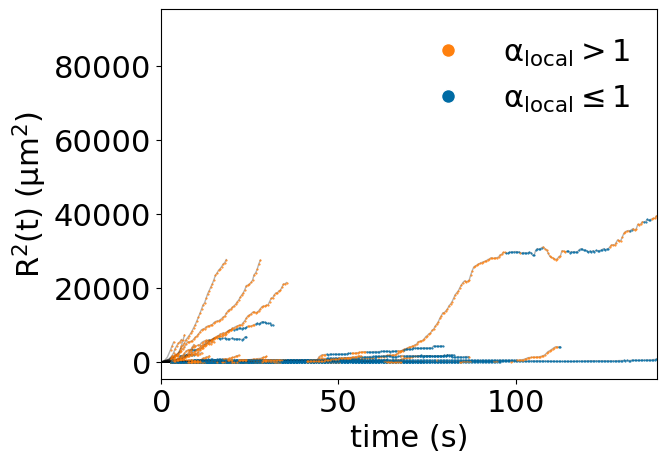

In [8]:
from scipy import signal
import pandas as pd
plt.rcParams.update({'font.size': 22})
fig,ax=plt.subplots(1)
sc_array,tot_intensity=[],[]

active_velocity,passive_coeff=[],[]
# alpha_values,cond_area=[],[]
count_condensates=0

for file_name in ['Individual_1.xlsx','Individual_2.xlsx','Individual_3.xlsx',\
                 'Individual_4.xlsx','Individual_5.xlsx','Individual_6.xlsx']:
    df=pd.read_excel('pARF7/'+file_name)
    
    non_zero=0
    
    for track_wa in df['TRACK_ID'].unique():
        if isinstance(track_wa, int):
            filtered_data=df[(df['TRACK_ID']==track_wa)]
            
        
            x_data=filtered_data['POSITION_X'].to_numpy().ravel()
            y_data=filtered_data['POSITION_Y'].to_numpy().ravel()
            time_data=filtered_data['T (s)'].to_numpy().ravel()
            T=12   ###Window time
            start_time=int(T/2)  ### Initial start time in \Delta R_t
            end_time=len(x_data)-int(T/2)
            
            if(end_time>0):
            
                t_data=[time_data[jk]-time_data[0] for jk in range(len(time_data))]
                p_a=[0 for i in range(end_time-start_time)]
            
                alpha,coeff,msd=piece_wise_msd(T,x_data,y_data)
                
                ax.plot(t_data[0:end_time],[((x_data[kl]-x_data[0])**2+(y_data[kl]-y_data[0])**2) for kl in range(0,end_time)],alpha=0.3,lw=1,color='k')
                
                for t_counter in range(len(alpha)):
                    if(alpha[t_counter]>1.) :
                        p_a[t_counter]=1
            
                        active_velocity.append(np.sqrt(np.exp(coeff[t_counter])))
            
                        kl=t_counter+int(T/2)
                        ax.plot(t_data[kl],((x_data[kl]-x_data[0])**2+(y_data[kl]-y_data[0])**2) ,marker='.',ms=1,color='#FF800E')
                    else:
                        p_a[t_counter]=0
                        kl=t_counter+int(T/2)
                        passive_coeff.append(np.exp(coeff[t_counter])/4)
                        ax.plot(t_data[kl],((x_data[kl]-x_data[0])**2+(y_data[kl]-y_data[0])**2) ,marker='.',ms=1,color='#006BA4')

ax.set_xlabel('time (s)')

ax.set_ylabel(r'$\mathrm {R^2(t) \;(\mu m^2)}$')

colors=['#FF800E','#006BA4']
labels=[r'$\mathrm{\alpha_{local}>1}$',r'$\mathrm{\alpha_{local} \leq 1}$']
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for color in colors]

ax.legend(handles, labels, loc='best',frameon=False)
plt.xlim([0,140])
#plt.ylim([0,200])
# #plt.ylim([0,20000])
# plt.yscale('log')
# plt.xscale('log')

plt.savefig("Active_vs_Passive/jpgs/pARF7.png",bbox_inches='tight')
plt.show()
        



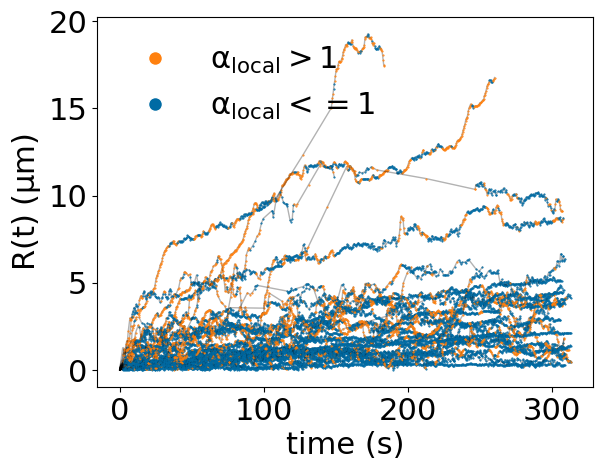

In [131]:
from scipy import signal
import pandas as pd
plt.rcParams.update({'font.size': 22})
fig,ax=plt.subplots(1)
sc_array,tot_intensity=[],[]

active_velocity,passive_coeff=[],[]
# alpha_values,cond_area=[],[]
count_condensates=0
for file_name in ['Individual_1.csv','Individual_2.csv','Individual_4.csv',\
                 'Individual_5.csv','Individual_7.csv']:
    df=pd.read_csv('pUBQ10/3ko/'+file_name)
    
    non_zero=0
    
    for track_wa in df['Condensate_ID'].unique():
        
        filtered_data=df[(df['Condensate_ID']==track_wa)]
        filtered_data=filtered_data[(filtered_data['Angle (degrees)'].notna())]

        x_data=filtered_data['x_position (um)'].to_numpy().ravel()
        y_data=filtered_data['y_position (um)'].to_numpy().ravel()
        time_data=filtered_data['Times (s)'].to_numpy().ravel()
        T=12   ###Window time
        start_time=int(T/2)  ### Initial start time in \Delta R_t
        end_time=len(x_data)-int(1*T/2)
        
        if(end_time>0):
            t_data=[time_data[jk]-time_data[0] for jk in range(len(time_data))]
            p_a=[0 for i in range(end_time-start_time)]
    
            alpha,coeff,msd=piece_wise_msd(T,x_data,y_data)
            ax.plot(t_data[0:end_time],[np.sqrt((x_data[kl]-x_data[0])**2+(y_data[kl]-y_data[0])**2) for kl in range(0,end_time)],alpha=0.3,lw=1,color='k')
            
            for t_counter in range(len(alpha)):
                if(alpha[t_counter]>1.) :
                    p_a[t_counter]=1
    
                    active_velocity.append(np.sqrt(np.exp(coeff[t_counter])))
    
                    kl=t_counter+int(T/2)
                    ax.plot(t_data[kl],np.sqrt((x_data[kl]-x_data[0])**2+(y_data[kl]-y_data[0])**2) ,marker='.',ms=1,color='#FF800E')
                else:
                    p_a[t_counter]=0
                    kl=t_counter+int(T/2)
                    passive_coeff.append(np.exp(coeff[t_counter])/4)
                    ax.plot(t_data[kl],np.sqrt((x_data[kl]-x_data[0])**2+(y_data[kl]-y_data[0])**2) ,marker='.',ms=1,color='#006BA4')

ax.set_xlabel('time (s)')

ax.set_ylabel(r'$\mathrm {R(t) \;(\mu m)}$')

colors=['#FF800E','#006BA4']
labels=[r'$\mathrm{\alpha_{local}>1}$',r'$\mathrm{\alpha_{local}<=1}$']
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for color in colors]

ax.legend(handles, labels, loc='best',frameon=False)
plt.savefig("Active_vs_Passive/jpgs/3ko_pUBQ10.jpg",bbox_inches='tight')
plt.show()
        



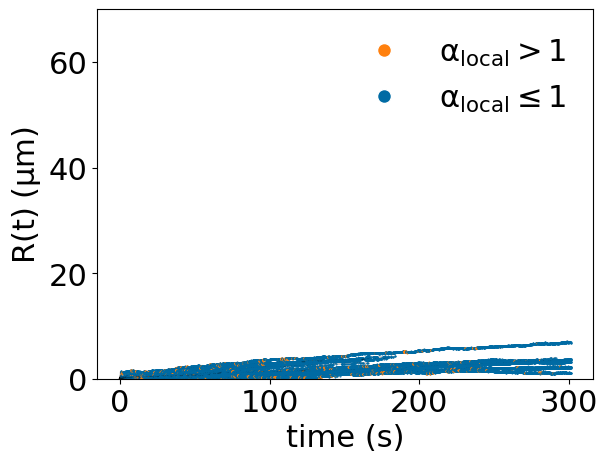

In [14]:
from scipy import signal
import pandas as pd
plt.rcParams.update({'font.size': 22})
fig,ax=plt.subplots(1)
sc_array,tot_intensity=[],[]

active_velocity,passive_coeff=[],[]
# alpha_values,cond_area=[],[]
count_condensates=0
for file_name in ['Individual_1.csv','Individual_3.csv','Individual_4.csv',\
                 'Individual_5.csv']:
    df=pd.read_csv('LatB/'+file_name)
    
    non_zero=0
    
    for track_wa in df['Condensate_ID'].unique():
        count_condensates+=1
        filtered_data=df[(df['Condensate_ID']==track_wa)]
        filtered_data=filtered_data[(filtered_data['Angle (degrees)'].notna())]
        
        x_data=filtered_data['x_position (um)'].to_numpy().ravel()
        y_data=filtered_data['y_position (um)'].to_numpy().ravel()
        time_data=filtered_data['Times (s)'].to_numpy().ravel()
        T=12   ###Window time
        start_time=int(T/2)  ### Initial start time in \Delta R_t
        end_time=len(x_data)-int(1*T/2)

        if(end_time>0):
            t_data=[time_data[jk]-time_data[0] for jk in range(len(time_data))]
            p_a=[0 for i in range(end_time-start_time)]
            
            alpha,coeff,msd=piece_wise_msd(T,x_data,y_data)
            ax.plot(t_data[0:end_time],[np.sqrt((x_data[kl]-x_data[0])**2+(y_data[kl]-y_data[0])**2) for kl in range(0,end_time)],alpha=0.3,lw=1,color='k')
            for t_counter in range(len(alpha)):
                if(alpha[t_counter]>1.) :
                    p_a[t_counter]=1
                    
                    active_velocity.append(np.sqrt(np.exp(coeff[t_counter])))
                    
                    kl=t_counter+int(T/2)
                    ax.plot(t_data[kl],np.sqrt((x_data[kl]-x_data[0])**2+(y_data[kl]-y_data[0])**2) ,marker='.',ms=1,color='#FF800E')
                else:
                    p_a[t_counter]=0
                    kl=t_counter+int(T/2)
                    passive_coeff.append(np.exp(coeff[t_counter])/4)
                    ax.plot(t_data[kl],np.sqrt((x_data[kl]-x_data[0])**2+(y_data[kl]-y_data[0])**2) ,marker='.',ms=1,color='#006BA4')

ax.set_xlabel('time (s)')

ax.set_ylabel(r'$\mathrm {R(t) \;(\mu m)}$')
plt.ylim([0,70])
plt.yticks((0,20,40,60))
colors=['#FF800E','#006BA4']
labels=[r'$\mathrm{\alpha_{local}>1}$',r'$\mathrm{\alpha_{local} \leq} 1$']
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for color in colors]

ax.legend(handles, labels, loc='best',frameon=False)

plt.savefig("Active_vs_Passive/pdfs/LatB_pARF19_xlim_60.pdf",bbox_inches='tight')
plt.show()
        

